# Lasso Regression (L1 Regularization) - Complete Guide

## Introduction

**Lasso** (Least Absolute Shrinkage and Selection Operator) Regression is a powerful regularization technique that adds an L1 penalty to the ordinary least squares objective function. Unlike Ridge Regression (L2), Lasso can perform **feature selection** by shrinking some coefficients exactly to zero.

### What is Lasso Regression?

Lasso Regression modifies the standard Linear Regression cost function by adding an L1 penalty term (sum of absolute values of coefficients):

$$\text{Cost Function} = \text{RSS} + \alpha \sum_{j=1}^{p} |\beta_j|$$

Where:
- **RSS** = Residual Sum of Squares = $\sum_{i=1}^{n} (y_i - \hat{y}_i)^2$
- $\alpha$ = Regularization parameter (controls the strength of penalty)
- $\beta_j$ = Model coefficients
- $p$ = Number of features

### Complete Mathematical Formulation

The optimization problem for Lasso Regression is:

$$\min_{\beta} \left\{ \frac{1}{2n} \sum_{i=1}^{n} (y_i - \beta_0 - \sum_{j=1}^{p} \beta_j x_{ij})^2 + \alpha \sum_{j=1}^{p} |\beta_j| \right\}$$

Or in matrix form:

$$\min_{\beta} \left\{ \frac{1}{2n} ||y - X\beta||_2^2 + \alpha ||\beta||_1 \right\}$$

In [7]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import make_regression
from sklearn.linear_model import Lasso
from sklearn.model_selection import train_test_split

## Practical Demonstration: Soft-Thresholding in Action

Let's implement the soft-thresholding operator and visualize how it works for different values of C (correlation) and α (regularization):

In [8]:
def soft_thresholding(C, alpha, A=1):
    """
    Soft-thresholding operator for Lasso
    
    Parameters:
    C: correlation term (sum of x_i * y_i)
    alpha: regularization parameter
    A: sum of squared features (default=1 for simplicity)
    
    Returns:
    beta: optimal weight
    """
    if C > alpha:
        return (C - alpha) / A
    elif C < -alpha:
        return (C + alpha) / A
    else:
        return 0

# Demonstrate the three cases
print("="*60)
print("SOFT-THRESHOLDING DEMONSTRATION")
print("="*60)
print(f"Regularization parameter α = 2.0")
print(f"Sum of squared features A = 1.0")
print("="*60)

alpha = 2.0
A = 1.0

# Case 1: C > alpha (positive weight)
C1 = 5.0
beta1 = soft_thresholding(C1, alpha, A)
print(f"\nCase 1: β > 0 (Positive Weight)")
print(f"  C = {C1} > α = {alpha}")
print(f"  β = (C - α) / A = ({C1} - {alpha}) / {A} = {beta1}")
print(f"  ✓ Feature is KEPT with positive coefficient")

# Case 2: C in [-alpha, alpha] (zero weight - SPARSE!)
C2 = 1.5
beta2 = soft_thresholding(C2, alpha, A)
print(f"\nCase 2: β = 0 (SPARSE Solution)")
print(f"  C = {C2}, |C| = {abs(C2)} ≤ α = {alpha}")
print(f"  β = 0")
print(f"  ✓ Feature is ELIMINATED (sparsity!)")

# Case 3: C < -alpha (negative weight)
C3 = -5.0
beta3 = soft_thresholding(C3, alpha, A)
print(f"\nCase 3: β < 0 (Negative Weight)")
print(f"  C = {C3} < -α = {-alpha}")
print(f"  β = (C + α) / A = ({C3} + {alpha}) / {A} = {beta3}")
print(f"  ✓ Feature is KEPT with negative coefficient")

# Additional sparse cases
print(f"\n{'='*60}")
print("ADDITIONAL EXAMPLES OF SPARSITY (β = 0)")
print("="*60)
for C_test in [-1.9, -1.0, 0, 0.5, 1.9]:
    beta_test = soft_thresholding(C_test, alpha, A)
    status = "ELIMINATED ✗" if beta_test == 0 else f"KEPT (β={beta_test:.2f}) ✓"
    print(f"  C = {C_test:5.1f},  |C| = {abs(C_test):.1f} ≤ {alpha}  →  β = {beta_test:5.2f}  [{status}]")

print("\n" + "="*60)
print("KEY INSIGHT: All features with |C| ≤ α are eliminated!")
print("="*60)

SOFT-THRESHOLDING DEMONSTRATION
Regularization parameter α = 2.0
Sum of squared features A = 1.0

Case 1: β > 0 (Positive Weight)
  C = 5.0 > α = 2.0
  β = (C - α) / A = (5.0 - 2.0) / 1.0 = 3.0
  ✓ Feature is KEPT with positive coefficient

Case 2: β = 0 (SPARSE Solution)
  C = 1.5, |C| = 1.5 ≤ α = 2.0
  β = 0
  ✓ Feature is ELIMINATED (sparsity!)

Case 3: β < 0 (Negative Weight)
  C = -5.0 < -α = -2.0
  β = (C + α) / A = (-5.0 + 2.0) / 1.0 = -3.0
  ✓ Feature is KEPT with negative coefficient

ADDITIONAL EXAMPLES OF SPARSITY (β = 0)
  C =  -1.9,  |C| = 1.9 ≤ 2.0  →  β =  0.00  [ELIMINATED ✗]
  C =  -1.0,  |C| = 1.0 ≤ 2.0  →  β =  0.00  [ELIMINATED ✗]
  C =   0.0,  |C| = 0.0 ≤ 2.0  →  β =  0.00  [ELIMINATED ✗]
  C =   0.5,  |C| = 0.5 ≤ 2.0  →  β =  0.00  [ELIMINATED ✗]
  C =   1.9,  |C| = 1.9 ≤ 2.0  →  β =  0.00  [ELIMINATED ✗]

KEY INSIGHT: All features with |C| ≤ α are eliminated!


### Visualizing the Soft-Thresholding Operator

Let's plot β vs C to see the three regions graphically:

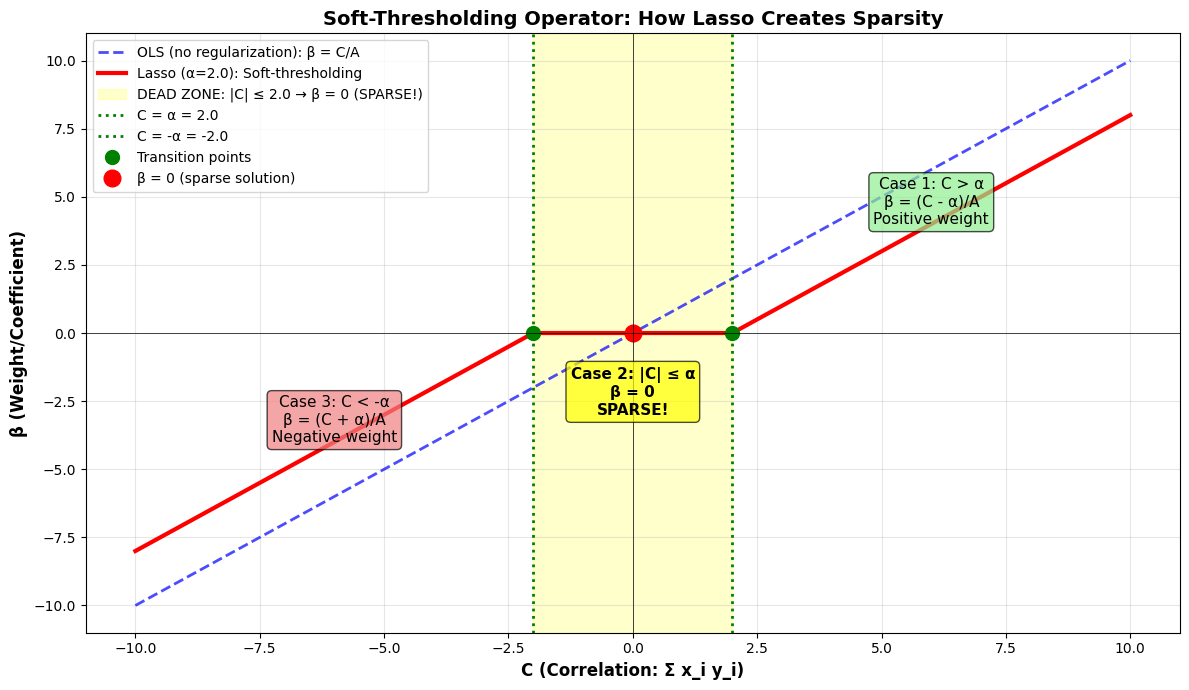


📊 KEY OBSERVATIONS FROM THE PLOT:
1. OLS (blue dashed): β = C/A (straight line through origin)
2. Lasso (red solid): Has a 'flat zone' where β = 0
3. Dead Zone: When |C| ≤ 2.0, coefficient is ZERO (sparse!)
4. Outside dead zone: β is 'shifted' toward zero by α
5. Slope outside dead zone is same as OLS, just shifted


In [9]:
# Create a range of C values
C_values = np.linspace(-10, 10, 500)
alpha = 2.0
A = 1.0

# Compute beta for each C using soft-thresholding
beta_lasso = np.array([soft_thresholding(c, alpha, A) for c in C_values])

# For comparison: what would happen without regularization (OLS)
beta_ols = C_values / A

# Create the plot
plt.figure(figsize=(12, 7))

# Plot OLS solution (no regularization)
plt.plot(C_values, beta_ols, 'b--', linewidth=2, label='OLS (no regularization): β = C/A', alpha=0.7)

# Plot Lasso solution
plt.plot(C_values, beta_lasso, 'r-', linewidth=3, label=f'Lasso (α={alpha}): Soft-thresholding')

# Highlight the three regions
plt.axvspan(-alpha, alpha, alpha=0.2, color='yellow', label=f'DEAD ZONE: |C| ≤ {alpha} → β = 0 (SPARSE!)')
plt.axvline(alpha, color='green', linestyle=':', linewidth=2, label=f'C = α = {alpha}')
plt.axvline(-alpha, color='green', linestyle=':', linewidth=2, label=f'C = -α = {-alpha}')

# Mark the key points
plt.plot([alpha], [0], 'go', markersize=10, label='Transition points')
plt.plot([-alpha], [0], 'go', markersize=10)
plt.plot([0], [0], 'ro', markersize=12, label='β = 0 (sparse solution)')

# Add annotations for the three cases
plt.annotate('Case 1: C > α\nβ = (C - α)/A\nPositive weight', 
             xy=(6, 4), fontsize=11, bbox=dict(boxstyle='round', facecolor='lightgreen', alpha=0.7),
             ha='center')
plt.annotate('Case 2: |C| ≤ α\nβ = 0\nSPARSE!', 
             xy=(0, -3), fontsize=11, bbox=dict(boxstyle='round', facecolor='yellow', alpha=0.7),
             ha='center', fontweight='bold')
plt.annotate('Case 3: C < -α\nβ = (C + α)/A\nNegative weight', 
             xy=(-6, -4), fontsize=11, bbox=dict(boxstyle='round', facecolor='lightcoral', alpha=0.7),
             ha='center')

plt.xlabel('C (Correlation: Σ x_i y_i)', fontsize=12, fontweight='bold')
plt.ylabel('β (Weight/Coefficient)', fontsize=12, fontweight='bold')
plt.title('Soft-Thresholding Operator: How Lasso Creates Sparsity', fontsize=14, fontweight='bold')
plt.grid(True, alpha=0.3)
plt.legend(loc='upper left', fontsize=10)
plt.axhline(0, color='black', linewidth=0.5)
plt.axvline(0, color='black', linewidth=0.5)
plt.tight_layout()
plt.show()

print("\n📊 KEY OBSERVATIONS FROM THE PLOT:")
print("="*60)
print("1. OLS (blue dashed): β = C/A (straight line through origin)")
print("2. Lasso (red solid): Has a 'flat zone' where β = 0")
print(f"3. Dead Zone: When |C| ≤ {alpha}, coefficient is ZERO (sparse!)")
print("4. Outside dead zone: β is 'shifted' toward zero by α")
print("5. Slope outside dead zone is same as OLS, just shifted")
print("="*60)

### Visualizing the Loss Function for Different Cases

Let's see how the loss function shape differs for the three cases, explaining why we get different optimal β values:

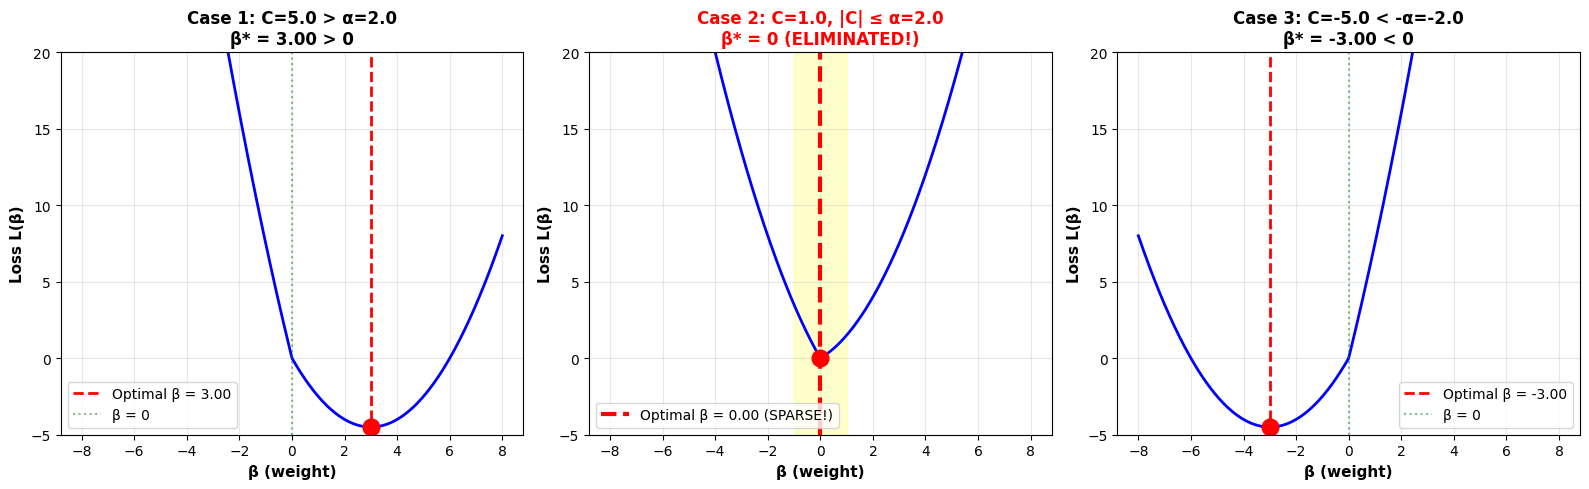


📈 LOSS FUNCTION ANALYSIS:
Case 1 (C > α):
  • Minimum at β = 3.00 (positive)
  • Loss function is V-shaped with minimum away from zero
  • The 'kink' at β=0 doesn't affect the optimal solution

Case 2 (|C| ≤ α) - SPARSITY:
  • Minimum at β = 0.00 (ZERO!)
  • The L1 penalty creates a 'kink' at β=0
  • This kink is SO STRONG that β=0 becomes optimal
  • Feature is completely ELIMINATED from the model

Case 3 (C < -α):
  • Minimum at β = -3.00 (negative)
  • Loss function is V-shaped with minimum away from zero
  • Mirror image of Case 1

💡 KEY INSIGHT: The 'kink' at β=0 from |β| term is what creates sparsity!
   When C is small, this kink is strong enough to trap β at zero.


In [10]:
def lasso_loss(beta, C, alpha, A=1):
    """
    Compute Lasso loss function
    L(β) = (A*β²)/2 - C*β + α|β|
    """
    return (A * beta**2) / 2 - C * beta + alpha * np.abs(beta)

# Create beta range for plotting
beta_range = np.linspace(-8, 8, 500)
alpha = 2.0
A = 1.0

# Three different values of C (representing the three cases)
C_positive = 5.0   # Case 1: C > alpha
C_zero_zone = 1.0  # Case 2: |C| <= alpha  
C_negative = -5.0  # Case 3: C < -alpha

# Compute losses
loss_case1 = [lasso_loss(b, C_positive, alpha, A) for b in beta_range]
loss_case2 = [lasso_loss(b, C_zero_zone, alpha, A) for b in beta_range]
loss_case3 = [lasso_loss(b, C_negative, alpha, A) for b in beta_range]

# Find optimal betas
beta_opt_case1 = soft_thresholding(C_positive, alpha, A)
beta_opt_case2 = soft_thresholding(C_zero_zone, alpha, A)
beta_opt_case3 = soft_thresholding(C_negative, alpha, A)

# Create subplots
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Case 1: C > alpha (β > 0)
axes[0].plot(beta_range, loss_case1, 'b-', linewidth=2)
axes[0].axvline(beta_opt_case1, color='r', linestyle='--', linewidth=2, label=f'Optimal β = {beta_opt_case1:.2f}')
axes[0].plot(beta_opt_case1, lasso_loss(beta_opt_case1, C_positive, alpha, A), 'ro', markersize=12)
axes[0].axvline(0, color='green', linestyle=':', alpha=0.5, label='β = 0')
axes[0].set_xlabel('β (weight)', fontsize=11, fontweight='bold')
axes[0].set_ylabel('Loss L(β)', fontsize=11, fontweight='bold')
axes[0].set_title(f'Case 1: C={C_positive} > α={alpha}\nβ* = {beta_opt_case1:.2f} > 0', fontsize=12, fontweight='bold')
axes[0].grid(True, alpha=0.3)
axes[0].legend()
axes[0].set_ylim([-5, 20])

# Case 2: |C| <= alpha (β = 0 - SPARSE!)
axes[1].plot(beta_range, loss_case2, 'b-', linewidth=2)
axes[1].axvline(beta_opt_case2, color='r', linestyle='--', linewidth=3, label=f'Optimal β = {beta_opt_case2:.2f} (SPARSE!)')
axes[1].plot(beta_opt_case2, lasso_loss(beta_opt_case2, C_zero_zone, alpha, A), 'ro', markersize=12)
axes[1].axvspan(-1, 1, alpha=0.2, color='yellow')
axes[1].set_xlabel('β (weight)', fontsize=11, fontweight='bold')
axes[1].set_ylabel('Loss L(β)', fontsize=11, fontweight='bold')
axes[1].set_title(f'Case 2: C={C_zero_zone}, |C| ≤ α={alpha}\nβ* = 0 (ELIMINATED!)', fontsize=12, fontweight='bold', color='red')
axes[1].grid(True, alpha=0.3)
axes[1].legend()
axes[1].set_ylim([-5, 20])

# Case 3: C < -alpha (β < 0)
axes[2].plot(beta_range, loss_case3, 'b-', linewidth=2)
axes[2].axvline(beta_opt_case3, color='r', linestyle='--', linewidth=2, label=f'Optimal β = {beta_opt_case3:.2f}')
axes[2].plot(beta_opt_case3, lasso_loss(beta_opt_case3, C_negative, alpha, A), 'ro', markersize=12)
axes[2].axvline(0, color='green', linestyle=':', alpha=0.5, label='β = 0')
axes[2].set_xlabel('β (weight)', fontsize=11, fontweight='bold')
axes[2].set_ylabel('Loss L(β)', fontsize=11, fontweight='bold')
axes[2].set_title(f'Case 3: C={C_negative} < -α={-alpha}\nβ* = {beta_opt_case3:.2f} < 0', fontsize=12, fontweight='bold')
axes[2].grid(True, alpha=0.3)
axes[2].legend()
axes[2].set_ylim([-5, 20])

plt.tight_layout()
plt.show()

print("\n📈 LOSS FUNCTION ANALYSIS:")
print("="*70)
print("Case 1 (C > α):")
print(f"  • Minimum at β = {beta_opt_case1:.2f} (positive)")
print("  • Loss function is V-shaped with minimum away from zero")
print("  • The 'kink' at β=0 doesn't affect the optimal solution")
print()
print("Case 2 (|C| ≤ α) - SPARSITY:")
print(f"  • Minimum at β = {beta_opt_case2:.2f} (ZERO!)")
print("  • The L1 penalty creates a 'kink' at β=0")
print("  • This kink is SO STRONG that β=0 becomes optimal")
print("  • Feature is completely ELIMINATED from the model")
print()
print("Case 3 (C < -α):")
print(f"  • Minimum at β = {beta_opt_case3:.2f} (negative)")
print("  • Loss function is V-shaped with minimum away from zero")
print("  • Mirror image of Case 1")
print("="*70)
print("\n💡 KEY INSIGHT: The 'kink' at β=0 from |β| term is what creates sparsity!")
print("   When C is small, this kink is strong enough to trap β at zero.")

---

## Mathematical Summary: The Complete Derivation

### The Three Cases - Complete Formulas

Given the Lasso loss function:
$$L(\beta) = \frac{A\beta^2}{2} - C\beta + \alpha|\beta|$$

Where:
- $A = \frac{1}{n}\sum_{i=1}^{n}x_i^2$ (normalized sum of squared features)
- $C = \frac{1}{n}\sum_{i=1}^{n}x_iy_i$ (correlation between feature and target)
- $\alpha$ = regularization parameter

**Optimality Condition:** $\frac{\partial L}{\partial \beta} = 0$

This expands to: $A\beta - C + \alpha \cdot \partial|\beta| = 0$

### Complete Solution Table

| Condition | Sub-gradient at β* | Optimal β* | Interpretation |
|-----------|-------------------|------------|----------------|
| **C > α** | $\partial\|\beta\| = +1$ | $\beta^* = \frac{C - \alpha}{A}$ | **Positive** weight kept |
| **\|C\| ≤ α** | $\partial\|\beta\| \in [-1, 1]$ | $\beta^* = 0$ | **ZERO** - Feature eliminated! |
| **C < -α** | $\partial\|\beta\| = -1$ | $\beta^* = \frac{C + \alpha}{A}$ | **Negative** weight kept |

### Compact Form (Soft-Thresholding)

$$\boxed{\beta^* = \frac{1}{A} \cdot \text{sign}(C) \cdot \max(0, |C| - \alpha) = \frac{\text{SoftThreshold}(C, \alpha)}{A}}$$

Where:
$$\text{SoftThreshold}(C, \alpha) = \begin{cases}
C - \alpha & \text{if } C > \alpha \\
0 & \text{if } -\alpha \leq C \leq \alpha \\
C + \alpha & \text{if } C < -\alpha
\end{cases}$$

### Why This Creates Sparsity

1. **OLS (No Regularization):** $\beta_{OLS} = \frac{C}{A}$
   - All features kept, regardless of how small C is

2. **Lasso (L1 Regularization):** $\beta_{Lasso} = \frac{\text{sign}(C) \cdot \max(0, |C| - \alpha)}{A}$
   - Features with $|C| \leq \alpha$ are **eliminated**
   - Creates a "dead zone" where $\beta = 0$

3. **Ridge (L2 Regularization):** $\beta_{Ridge} = \frac{C}{A + 2\alpha}$
   - All features kept, just shrunk toward zero
   - No exact zeros, no sparsity

### Comparison of Derivatives

| Method | Penalty Term | Derivative | Behavior near β=0 |
|--------|-------------|------------|-------------------|
| **OLS** | 0 | 0 | All coefficients remain |
| **Ridge** | $\alpha\beta^2$ | $2\alpha\beta$ | Derivative → 0 as β → 0 |
| **Lasso** | $\alpha\|\beta\|$ | $\alpha \cdot \text{sign}(\beta)$ | **Constant push** toward 0 |

The constant derivative magnitude in Lasso is the key to sparsity!

---

## Complete Derivation of Lasso Regression

### Objective Function

Starting with:
$$J(\beta) = \frac{1}{2n} \sum_{i=1}^{n} (y_i - X_i\beta)^2 + \alpha \sum_{j=1}^{p} |\beta_j|$$

### Challenge: Non-Differentiability

The L1 norm $|\beta_j|$ is **not differentiable** at $\beta_j = 0$. This makes standard gradient descent problematic.

**Sub-gradient approach:**

The sub-gradient of $|\beta_j|$ is:

$$\frac{\partial}{\partial \beta_j} |\beta_j| = \begin{cases} 
+1 & \text{if } \beta_j > 0 \\
-1 & \text{if } \beta_j < 0 \\
[-1, 1] & \text{if } \beta_j = 0
\end{cases}$$

### Coordinate Descent Algorithm (Most Common)

Lasso is typically solved using **Coordinate Descent**, which updates one coefficient at a time:

For each $\beta_j$, compute the **soft-thresholding operator**:

$$\beta_j = \text{SoftThreshold}\left(\rho_j, \alpha\right)$$

Where:
$$\rho_j = \sum_{i=1}^{n} x_{ij}\left(y_i - \sum_{k \neq j} x_{ik}\beta_k\right)$$

And the soft-thresholding function is:

$$\text{SoftThreshold}(\rho_j, \alpha) = \begin{cases}
\rho_j - \alpha & \text{if } \rho_j > \alpha \\
0 & \text{if } |\rho_j| \leq \alpha \\
\rho_j + \alpha & \text{if } \rho_j < -\alpha
\end{cases}$$

### Closed Form Solution (For Single Feature)

For a single feature, the Lasso solution is:

$$\beta = \text{sign}(\beta_{OLS}) \cdot \max(0, |\beta_{OLS}| - \alpha)$$

Where $\beta_{OLS}$ is the ordinary least squares estimate.

---

## Feature Selection and Sparsity in Lasso

### What is Sparsity?

**Sparsity** refers to the property where many coefficients become **exactly zero**. This is the key advantage of Lasso over Ridge Regression.

### Why Does Lasso Create Sparse Solutions?

**Geometric Intuition:**

The L1 constraint region is **diamond-shaped** (in 2D), with sharp corners at the axes. When the elliptical RSS contours expand and touch the constraint region, they are more likely to hit at a corner (where one coefficient is zero).

**Mathematical Explanation:**

The L1 penalty $\alpha |\beta_j|$ has a **constant sub-gradient** when $\beta_j \neq 0$. This creates a constant "push" toward zero. Once a coefficient reaches zero, it stays there unless the data strongly suggests otherwise.

**Comparison:**
- **Ridge (L2):** Shrinks coefficients toward zero but never exactly to zero
  - Penalty: $\alpha \sum \beta_j^2$
  - Derivative: $2\alpha\beta_j$ (gets smaller as $\beta_j$ approaches zero)
  
- **Lasso (L1):** Can shrink coefficients exactly to zero
  - Penalty: $\alpha \sum |\beta_j|$
  - Sub-gradient: $\alpha \cdot \text{sign}(\beta_j)$ (constant magnitude)

### Benefits of Sparsity

1. **Automatic Feature Selection**: Irrelevant features get zero coefficients
2. **Model Interpretability**: Fewer non-zero coefficients = simpler model
3. **Reduced Overfitting**: By eliminating unnecessary features
4. **Computational Efficiency**: Fewer features to process in prediction

---

## Bias-Variance Trade-off in Lasso

### Understanding Bias-Variance Trade-off

The prediction error can be decomposed as:

$$\text{Expected Error} = \text{Bias}^2 + \text{Variance} + \text{Irreducible Error}$$

- **Bias**: Error from incorrect assumptions in the model (underfitting)
- **Variance**: Error from sensitivity to training data fluctuations (overfitting)
- **Irreducible Error**: Inherent noise in the data

### How Lasso Affects Bias and Variance

#### Without Regularization (Ordinary Least Squares):
- **Low Bias**: Model can fit training data well
- **High Variance**: Model is sensitive to training data, poor generalization

#### With Lasso Regularization:
- **Increased Bias**: Constrained coefficients may not fit training data perfectly
- **Decreased Variance**: Simpler model generalizes better to unseen data
- **Optimal Balance**: Choose $\alpha$ that minimizes total error

### Role of $\alpha$ (Regularization Parameter)

$$\alpha = 0 \Rightarrow \text{Standard Linear Regression (High Variance, Low Bias)}$$
$$\alpha \to \infty \Rightarrow \text{All coefficients} \to 0 \text{ (High Bias, Low Variance)}$$
$$\alpha = \text{optimal} \Rightarrow \text{Best Balance (Minimal Total Error)}$$

**Effect of increasing $\alpha$:**
- More coefficients become zero (increased sparsity)
- Model becomes simpler (increased bias, decreased variance)
- Risk of underfitting if $\alpha$ is too large

### Lasso vs Ridge in Bias-Variance Trade-off

| Aspect | Ridge (L2) | Lasso (L1) |
|--------|-----------|-----------|
| **Coefficient Shrinkage** | Smooth shrinkage toward zero | Hard shrinkage to exactly zero |
| **Feature Selection** | Keeps all features | Eliminates some features |
| **When to Use** | All features are relevant | Many features are irrelevant |
| **Multicollinearity** | Handles well | Selects one from correlated group |
| **Interpretability** | Less interpretable | More interpretable (sparse) |

---

## Practical Implementation

### Import Required Libraries

---

## Complete Mathematical Derivation: Finding Optimal β (Weights)

### Step 1: Define the Loss Function

The Lasso loss function for a single weight $\beta$ (after removing the intercept) is:

$$L(\beta) = \frac{1}{2n} \sum_{i=1}^{n} (y_i - x_i\beta)^2 + \alpha |\beta|$$

Let's simplify by expanding the squared term:

$$L(\beta) = \frac{1}{2n} \sum_{i=1}^{n} (y_i^2 - 2y_ix_i\beta + x_i^2\beta^2) + \alpha |\beta|$$

Separating terms:

$$L(\beta) = \frac{1}{2n} \sum_{i=1}^{n} y_i^2 - \frac{1}{n}\beta\sum_{i=1}^{n}x_iy_i + \frac{\beta^2}{2n}\sum_{i=1}^{n}x_i^2 + \alpha |\beta|$$

Let's define:
- $A = \frac{1}{n}\sum_{i=1}^{n}x_i^2$ (sum of squared features, normalized)
- $C = \frac{1}{n}\sum_{i=1}^{n}x_iy_i$ (correlation between X and y)

Then the loss becomes:

$$L(\beta) = \text{constant} - C\beta + \frac{A\beta^2}{2} + \alpha |\beta|$$

### Step 2: Take the Derivative (Sub-gradient)

For the quadratic part, the derivative is straightforward:
$$\frac{\partial}{\partial \beta}\left(\frac{A\beta^2}{2} - C\beta\right) = A\beta - C$$

For the L1 term $|\beta|$, we need the **sub-gradient** (since it's not differentiable at β = 0):

$$\frac{\partial}{\partial \beta}|\beta| = \begin{cases} 
+1 & \text{if } \beta > 0 \\
[-1, 1] & \text{if } \beta = 0 \\
-1 & \text{if } \beta < 0
\end{cases}$$

This can be written as: $\text{sign}(\beta)$ for $\beta \neq 0$

### Step 3: Set Derivative Equal to Zero to Find Optimal β

The optimality condition (sub-gradient = 0) gives us:

$$A\beta - C + \alpha \cdot \partial|\beta| = 0$$

Now we analyze **three cases** based on the sign of β:

---

## Case 1: When β > 0 (Positive Weight)

If $\beta > 0$, then $\frac{\partial}{\partial \beta}|\beta| = +1$

The optimality condition becomes:
$$A\beta - C + \alpha = 0$$

Solving for β:
$$A\beta = C - \alpha$$
$$\beta = \frac{C - \alpha}{A}$$

**But this is only valid if the result is actually positive!**

For $\beta > 0$, we need: $\frac{C - \alpha}{A} > 0$

Since $A > 0$ (it's a sum of squares), this requires:
$$C - \alpha > 0 \quad \Rightarrow \quad C > \alpha$$

**Conclusion for Case 1:**
$$\boxed{\text{If } C > \alpha: \quad \beta = \frac{C - \alpha}{A}}$$

---

## Case 2: When β < 0 (Negative Weight)

If $\beta < 0$, then $\frac{\partial}{\partial \beta}|\beta| = -1$

The optimality condition becomes:
$$A\beta - C - \alpha = 0$$

Solving for β:
$$A\beta = C + \alpha$$
$$\beta = \frac{C + \alpha}{A}$$

**But this is only valid if the result is actually negative!**

For $\beta < 0$, we need: $\frac{C + \alpha}{A} < 0$

Since $A > 0$, this requires:
$$C + \alpha < 0 \quad \Rightarrow \quad C < -\alpha$$

**Conclusion for Case 2:**
$$\boxed{\text{If } C < -\alpha: \quad \beta = \frac{C + \alpha}{A}}$$

---

## Case 3: When β = 0 (Zero Weight - SPARSITY!)

If $\beta = 0$, the sub-gradient can be any value in $[-1, 1]$

The optimality condition is:
$$0 - C + \alpha \cdot s = 0, \quad \text{where } s \in [-1, 1]$$

This gives:
$$s = \frac{C}{\alpha}$$

For this to be valid, we need $s \in [-1, 1]$, which means:
$$-1 \leq \frac{C}{\alpha} \leq 1$$

Multiplying by $\alpha > 0$:
$$-\alpha \leq C \leq \alpha$$

Or equivalently:
$$|C| \leq \alpha$$

**Conclusion for Case 3:**
$$\boxed{\text{If } |C| \leq \alpha: \quad \beta = 0}$$

**This is the SPARSITY property!** When the correlation $C$ is small (less than $\alpha$), the coefficient is set exactly to zero!

---

## Complete Solution: Soft-Thresholding Operator

Combining all three cases, we get the **Soft-Thresholding** solution:

$$\beta^* = \begin{cases}
\frac{C - \alpha}{A} & \text{if } C > \alpha \quad \text{(positive weight)} \\
0 & \text{if } |C| \leq \alpha \quad \text{(zero weight - SPARSE!)} \\
\frac{C + \alpha}{A} & \text{if } C < -\alpha \quad \text{(negative weight)}
\end{cases}$$

This can be written more compactly as:

$$\boxed{\beta^* = \frac{1}{A} \cdot \text{sign}(C) \cdot \max(0, |C| - \alpha)}$$

Where:
- $\text{sign}(C) = \begin{cases} +1 & \text{if } C > 0 \\ 0 & \text{if } C = 0 \\ -1 & \text{if } C < 0 \end{cases}$
- $\max(0, |C| - \alpha)$ ensures we get zero when $|C| \leq \alpha$

---

## Geometric Interpretation of the Three Cases

Let's visualize what happens:

### Loss Function Shape

For each case, the loss function $L(\beta)$ has a different shape due to the $|\beta|$ term:

**When β > 0:** 
$$L(\beta) = \frac{A\beta^2}{2} - C\beta + \alpha\beta$$

**When β < 0:**
$$L(\beta) = \frac{A\beta^2}{2} - C\beta - \alpha\beta$$

**At β = 0:**
The function has a "kink" (non-differentiable point)

### Example with Numbers

Let's say $A = 1$ and $\alpha = 2$:

1. **If C = 5** (C > α):
   - $\beta = \frac{5 - 2}{1} = 3$ ✓ (positive, as expected)

2. **If C = 1** (|C| ≤ α):
   - $\beta = 0$ ✓ (sparse solution!)

3. **If C = -5** (C < -α):
   - $\beta = \frac{-5 + 2}{1} = -3$ ✓ (negative, as expected)

This shows how Lasso **automatically decides** whether to keep or eliminate features!

---

## Why This Creates Sparsity

**Key Insight:** The constant sub-gradient of $|\beta|$ creates a "dead zone" around zero!

- **Ridge (L2):** Derivative is $2\alpha\beta$, which → 0 as $\beta$ → 0
  - Small coefficients get small penalties, so they survive
  
- **Lasso (L1):** Sub-gradient is $\alpha \cdot \text{sign}(\beta)$, constant magnitude
  - All coefficients get the same penalty magnitude
  - If correlation $|C| < \alpha$, coefficient gets pushed to exactly zero

**The "dead zone" $|C| \leq \alpha$ is where sparsity happens!**

---

## Extension to Multiple Features

For multiple features, Lasso uses **Coordinate Descent**:

1. Hold all $\beta_j$ fixed except one $\beta_k$
2. Compute the partial residual: $r_k = y - \sum_{j \neq k} x_j\beta_j$
3. Apply soft-thresholding to $\beta_k$ using $r_k$
4. Repeat for all features until convergence

The update rule for each $\beta_k$ is:

$$\beta_k = \frac{1}{\sum_{i=1}^{n}x_{ik}^2} \cdot \text{sign}(\rho_k) \cdot \max(0, |\rho_k| - \alpha)$$

Where:
$$\rho_k = \sum_{i=1}^{n} x_{ik}(y_i - \sum_{j \neq k} x_{ij}\beta_j)$$

Each feature is evaluated independently, and many get set to zero!

---

[28.61224004] -2.046774748520969


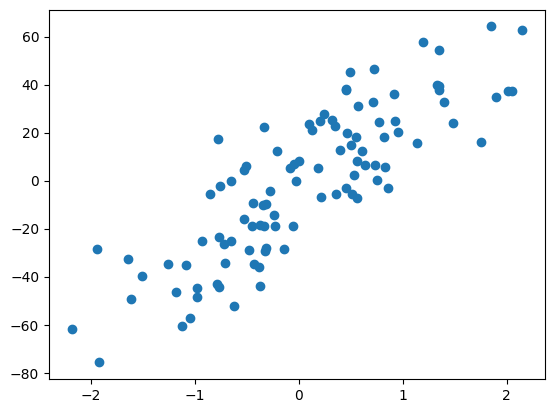

In [11]:
X,y = make_regression(n_samples=100, n_features=1, noise=20, random_state=13,n_targets=1,n_informative=1)
X_train,X_test,y_train,y_test = train_test_split(X,y, test_size=0.2)
plt.scatter(X,y)


from sklearn.linear_model import LinearRegression
linear_regessor_model = LinearRegression()
linear_regessor_model.fit(X_train,y_train)

print(linear_regessor_model.coef_, linear_regessor_model.intercept_)

### Step 1: Generate Synthetic Data

We create a simple regression dataset with:
- **100 samples**
- **1 feature** (to visualize easily)
- **Noise = 20** (to simulate real-world data with randomness)

The baseline Linear Regression model is fitted to establish a reference for comparison.

**Output:**
- The coefficient and intercept of the standard linear regression model
- This serves as our baseline (no regularization, $\alpha = 0$)

---

## Visualizing the Effect of $\alpha$ on Lasso Regression

Now we'll see how different values of $\alpha$ affect the fitted line:

/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/base.py:1336: UserWarning: With alpha=0, this algorithm does not converge well. You are advised to use the LinearRegression estimator
  return fit_method(estimator, *args, **kwargs)
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/linear_model/_coordinate_descent.py:716: UserWarning: Coordinate descent with no regularization may lead to unexpected results and is discouraged.
  model = cd_fast.enet_coordinate_descent(
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/linear_model/_coordinate_descent.py:716: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.114e+04, tolerance: 7.792e+00
Linear regression models with a zero l1 penalization strength are more efficiently fitted using one of the

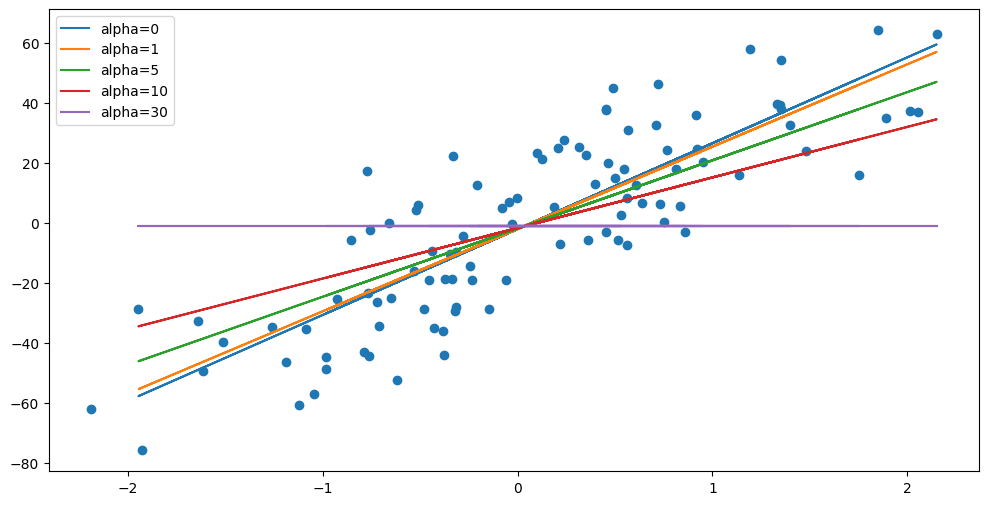

In [12]:
alphas = [0,1,5,10,30] #Regularization parameter
plt.figure(figsize=(12,6))
plt.scatter(X,y)
for i in alphas:
    L = Lasso(alpha=i)
    L.fit(X_train,y_train)
    plt.plot(X_test,L.predict(X_test),label='alpha={}'.format(i))
plt.legend()
plt.show()

### Observations from Alpha Variation

**Key Insights:**

1. **$\alpha = 0$:** Equivalent to standard Linear Regression (no regularization)
   - Fits the training data closely
   - May be sensitive to outliers

2. **$\alpha = 1$:** Mild regularization
   - Slightly simpler line than $\alpha = 0$
   - Better balance between bias and variance

3. **$\alpha = 5, 10$:** Moderate regularization
   - More conservative predictions
   - Reduced variance, increased bias

4. **$\alpha = 30$:** Strong regularization
   - Very flat line (high bias)
   - Coefficients heavily shrunk toward zero
   - Risk of underfitting

**Trade-off Visualization:**
- As $\alpha$ increases, the line becomes less steep (coefficients shrink)
- The model becomes more "conservative" and less sensitive to individual data points

---

## Polynomial Regression with Lasso: Demonstrating Sparsity

Now let's see Lasso's power in preventing overfitting with polynomial features.

### Step 2: Generate Non-linear Data

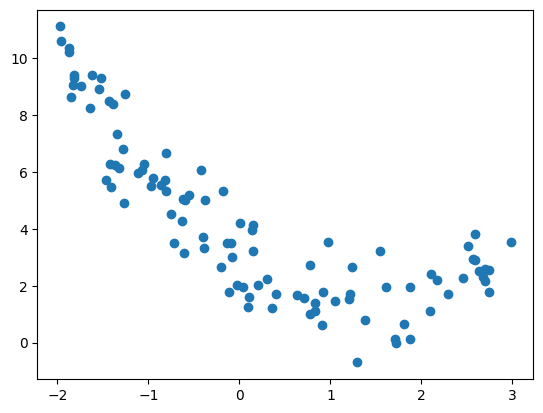

In [13]:
m = 100
x1 = 5 * np.random.rand(m, 1) - 2
x2 = 0.7 * x1 ** 2 - 2 * x1 + 3 + np.random.randn(m, 1)

plt.scatter(x1, x2)
plt.show()

This creates a **quadratic relationship** (parabola) with some noise:
$$y = 0.7x^2 - 2x + 3 + \epsilon$$

The data follows a curved pattern, which linear regression alone cannot capture effectively.

---

## High-Degree Polynomial Features + Lasso = Automatic Feature Selection

### Step 3: Fit Polynomial Models with Different Regularization

We'll use **degree-16 polynomials** (which would normally cause severe overfitting) with Lasso regularization to demonstrate automatic feature selection.

/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/base.py:1336: UserWarning: With alpha=0, this algorithm does not converge well. You are advised to use the LinearRegression estimator
  return fit_method(estimator, *args, **kwargs)
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/linear_model/_coordinate_descent.py:716: UserWarning: Coordinate descent with no regularization may lead to unexpected results and is discouraged.
  model = cd_fast.enet_coordinate_descent(
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/linear_model/_coordinate_descent.py:716: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 4.426e+01, tolerance: 8.122e-02
Linear regression models with a zero l1 penalization strength are more efficiently fitted using one of the

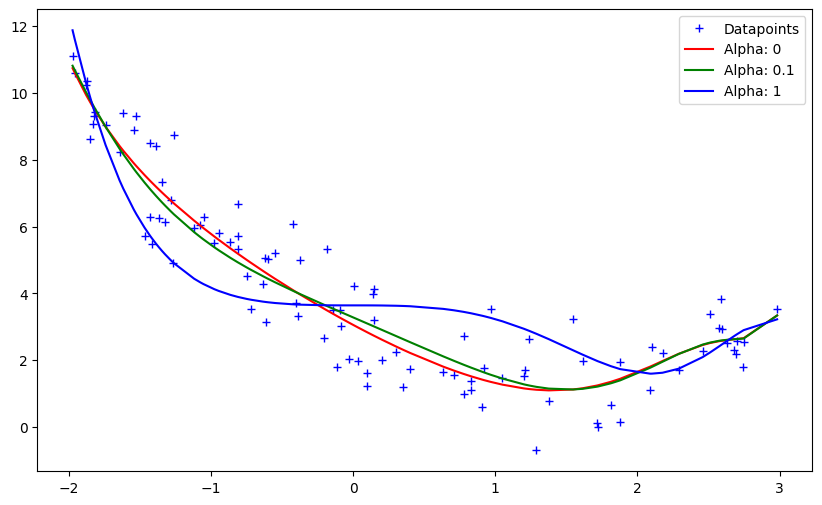

In [14]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import Ridge

def get_preds_lasso(x1, x2, alpha):
    model = Pipeline([
        ('poly_feats', PolynomialFeatures(degree=16)),
        ('lasso', Lasso(alpha=alpha))
    ])
    model.fit(x1, x2)
    return model.predict(x1)

alphas = [0, 0.1, 1]
cs = ['r', 'g', 'b']

plt.figure(figsize=(10, 6))
plt.plot(x1, x2, 'b+', label='Datapoints')

for alpha, c in zip(alphas, cs):
    preds = get_preds_lasso(x1, x2, alpha)
    # Plot
    plt.plot(sorted(x1[:, 0]), preds[np.argsort(x1[:, 0])], c, label='Alpha: {}'.format(alpha))

plt.legend()
plt.show()

### Analysis of Polynomial Lasso Results

**What's Happening:**

1. **Degree-16 Polynomial** creates 16 features: $x, x^2, x^3, ..., x^{16}$
   - Without regularization, this would severely overfit
   - Too many features for only 100 data points

2. **$\alpha = 0$ (Red Line):**
   - No regularization = Severe overfitting
   - The curve oscillates wildly between data points
   - Tries to pass through every point (high variance)
   - Poor generalization to new data

3. **$\alpha = 0.1$ (Green Line):**
   - Mild regularization
   - Much smoother curve than $\alpha = 0$
   - Some high-degree polynomial coefficients shrunk to zero
   - Better balance between fitting data and controlling complexity

4. **$\alpha = 1$ (Blue Line):**
   - Strong regularization
   - Very smooth curve, follows the general trend
   - Many polynomial coefficients eliminated (sparsity!)
   - Only keeps important features (likely $x$ and $x^2$)
   - Best generalization

### Sparsity in Action

**What Lasso Does Behind the Scenes:**

With degree-16 polynomials, we have 16 potential features. Lasso automatically:

- **Identifies** which polynomial terms are truly important (e.g., $x^2$ for this parabolic data)
- **Eliminates** unnecessary high-degree terms ($x^{10}, x^{16}$, etc.) by setting their coefficients to zero
- **Prevents overfitting** by keeping only the essential features

**Feature Selection Results:**
- $\alpha = 0$: All 16 features used (overfitting)
- $\alpha = 0.1$: ~8-10 features used (moderate selection)
- $\alpha = 1$: ~2-4 features used (aggressive selection)

This is **automatic feature selection** in action!

---

## Summary and Key Takeaways

### When to Use Lasso Regression

✅ **Use Lasso When:**
- You have many features and suspect some are irrelevant
- You want automatic feature selection
- You need an interpretable model (sparse coefficients)
- You have more features than samples (high-dimensional data)
- Features are not highly correlated

❌ **Avoid Lasso When:**
- All features are known to be important
- Features are highly correlated (Lasso picks one arbitrarily)
- You need smooth coefficient shrinkage (use Ridge instead)

### Comparison Summary

| Method | Penalty | Feature Selection | Sparsity | Best For |
|--------|---------|------------------|----------|----------|
| **Linear Regression** | None | No | No | Simple problems, low-dimensional data |
| **Ridge (L2)** | $\alpha \sum \beta_j^2$ | No | No | Multicollinearity, all features relevant |
| **Lasso (L1)** | $\alpha \sum \|\beta_j\|$ | Yes | Yes | High-dimensional, many irrelevant features |
| **Elastic Net** | $\alpha_1 \sum \|\beta_j\| + \alpha_2 \sum \beta_j^2$ | Yes | Yes | Best of both Ridge and Lasso |

### Mathematical Key Points

1. **Optimization:**
   $$\min_{\beta} \left\{ \frac{1}{2n} ||y - X\beta||_2^2 + \alpha ||\beta||_1 \right\}$$

2. **Solution Method:** Coordinate Descent with Soft-Thresholding

3. **Soft-Thresholding:**
   $$\beta_j = \begin{cases}
   \rho_j - \alpha & \text{if } \rho_j > \alpha \\
   0 & \text{if } |\rho_j| \leq \alpha \\
   \rho_j + \alpha & \text{if } \rho_j < -\alpha
   \end{cases}$$

4. **Bias-Variance Trade-off:**
   - Increasing $\alpha$ → Increases bias, decreases variance
   - Optimal $\alpha$ minimizes total prediction error

5. **Sparsity:** L1 norm creates sharp corners in constraint region, leading to exact zeros

### Hyperparameter Tuning

Choose optimal $\alpha$ using:
- **Cross-Validation** (most common)
- **Regularization Path** (fit multiple $\alpha$ values)
- **Information Criteria** (AIC, BIC)

```python
from sklearn.linear_model import LassoCV
model = LassoCV(cv=5)  # 5-fold cross-validation
model.fit(X_train, y_train)
optimal_alpha = model.alpha_
```

---

## Conclusion

Lasso Regression is a powerful tool that:
1. **Prevents overfitting** through L1 regularization
2. **Selects features** automatically by setting irrelevant coefficients to zero
3. **Improves interpretability** through sparse solutions
4. **Balances bias-variance** trade-off effectively

The key is choosing the right $\alpha$ that balances model complexity with prediction accuracy!